# LangGraph Basic Demo

This notebook walks through building a ReAct agent from scratch using LangGraph.

## What is LangGraph?

LangGraph is a framework for agent orchestration that can:
- Control the flow of an agent between steps (nodes)
- Make long-running execution robust to failures
- Incorporate human-in-the-loop
- Provide short-term and long-term memory
- Deploy production ready agents with provided UIs
- Work with LangChain or any other frameworks

---
## 1. Define Tools & Models

Tools are functions the LLM can call. After defining tools, we **bind them to the model** so the LLM knows what tools are available and how to call them.

In [51]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

load_dotenv()

# Define the model
model = ChatOpenAI(model="gpt-5-mini", temperature=0)

# Define tools
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city.
    
    Args:
        city: The name of the city to get weather for.
    """
    return f"The weather in {city} is 72F and sunny."

@tool
def add_numbers(a: float, b: float) -> float:
    """Add two numbers together and return the sum.
    
    Args:
        a: The first number.
        b: The second number.
    """
    return a + b

# Create tools list
tools = [get_weather, add_numbers]

# Bind tools to the model
model_with_tools = model.bind_tools(tools)

---
## 2. Define State Schema

**State** is the data our graph carries through execution. Each run starts with a fresh State instance.

### Reducers

Reducers dictate how state is updated when a node returns new values. They're especially important when **multiple nodes write to the same state key simultaneously** (e.g., during a super-step where nodes run in parallel). Without a reducer, you'd have a conflict—reducers resolve this by defining how to merge the updates.

![Concurrent node updates](../assets/images/nodes.png)

The `add_messages` reducer ensures new messages are **appended** to the existing list rather than replacing it.

Using **Pydantic** for type enforcing.

In [52]:
from typing import Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class MessagesState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages] = Field(default_factory=list)
    llm_calls: int = 0

---
## 3. Define Nodes

**Nodes** are functions that make changes to state via calling LLMs or executing logic. Nodes can be:
- **LLM calls** (e.g., calling a model to generate text)
- **Tool invocations** (e.g., Python functions, API calls)
- **Control flow** elements (e.g., branching, loops)
- **State transformers** (e.g., reading/updating graph state)
- **Subgraphs** (a node can itself be a nested graph)

### Why Use ToolNode?

A `ToolNode` is a dedicated node whose only job is to execute tools. It's **best practice** to use `ToolNode` instead of letting the LLM call tools within a node because it provides:
- Clean **name→function mapping** for tool lookup
- Automatic **argument parsing** from LLM output
- Proper **`ToolMessage` generation** returned to state
- Support for **multiple tool calls** in a single turn
- Better **observability, error handling, and retries**

In [53]:
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            model_with_tools.invoke(
                [SystemMessage(content="You are a helpful assistant.")]
                + state.messages
            )
        ],
        "llm_calls": state.llm_calls + 1
    }

# Use prebuilt ToolNode instead of custom function
tool_node = ToolNode(tools)

---
## 4. Define Conditional Edges

**Conditional edges** are functions that choose the next node based on state. They enable dynamic routing—for example, deciding whether to execute a tool or return a final response to the user.

In [54]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    """Decide if we should continue the loop or stop based on whether the LLM made a tool call"""
    last_message = state.messages[-1]
    
    if last_message.tool_calls:
        return "tool_node"
    return END

---
## 5. Build Agent

Connect nodes with edges and conditional edges to form a graph. 

- `add_edge(A, B)` - Always go from A to B
- `add_conditional_edges(A, func, [...])` - Use `func` to decide where to go from A

In [55]:
from langgraph.graph import StateGraph, START, END

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

---
## 6. Compile

Take the graph blueprint and make it into an executable graph.

At compile time, you can optionally provide:
- **Checkpointer** for short-term memory (conversation history)
- **Memory store** for long-term memory (persistent across sessions)

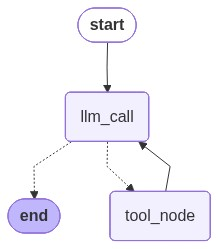

In [56]:
import re
import base64
import requests
from IPython.display import Image, display

# Compile the agent
agent = agent_builder.compile()

# Workaround: LangGraph 1.0.5 adds <p> tags that mermaid.ink API rejects
def draw_graph(graph):
    mermaid = graph.get_graph().draw_mermaid()
    clean = re.sub(r'<p>|</p>', '', mermaid)
    encoded = base64.urlsafe_b64encode(clean.encode('utf-8')).decode('utf-8')
    return requests.get(f'https://mermaid.ink/img/{encoded}', timeout=10).content

display(Image(draw_graph(agent)))

---
## 7. Run the Graph

We can run the graph from a notebook, deploy it locally, or deploy it on external servers.

In [57]:
from langchain_core.messages import HumanMessage

# Demo 1: Math tool
result = agent.invoke({"messages": [HumanMessage(content="Add 15 and 27 for me.")]})

for msg in result["messages"]:
    msg.pretty_print()

print(f"\nTotal LLM calls: {result['llm_calls']}")

================================ Human Message =================================

Add 15 and 27 for me.
================================== Ai Message ==================================

15 + 27 = 42.

Total LLM calls: 1


In [58]:
# Demo 2: Weather tool
result = agent.invoke({"messages": [HumanMessage(content="What's the weather in Tokyo?")]})

for msg in result["messages"]:
    msg.pretty_print()

print(f"\nTotal LLM calls: {result['llm_calls']}")

================================ Human Message =================================

What's the weather in Tokyo?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_dh6R7QmnQxpgMOpL9srjV7Di)
 Call ID: call_dh6R7QmnQxpgMOpL9srjV7Di
  Args:
    city: Tokyo
================================= Tool Message =================================
Name: get_weather

The weather in Tokyo is 72F and sunny.
================================== Ai Message ==================================

The weather in Tokyo is 72°F and sunny.

Total LLM calls: 2


---
# Additional Concepts

## Best Practices for Nodes

**Split logical steps into separate nodes** rather than combining them:
- Checkpointing happens at each node, so if all logic is in one node, failures require restarting everything
- Makes it easy to swap out individual nodes when iterating

**Tasks for complex nodes:** If a node contains multiple operations, convert each operation into a `@task` rather than refactoring into individual nodes. This enables checkpointing per task instead of per superstep, so if one part of a node fails, you don't need to restart the whole node:

```python
@task
def _make_request(url: str):
    """Make a request."""
    return requests.get(url).text[:100]
```

---

## How ToolNode Works Internally

When you use `ToolNode`, it:
1. Takes your tools and stores them as a **name→function mapping**
2. When the LLM outputs a tool call, the graph routes to the ToolNode
3. The ToolNode **extracts the call**, **matches the tool name**, **parses the arguments**
4. **Runs the function** and returns a `ToolMessage` back into the state
5. Supports **multiple tool calls**, **loops**, and **clean tracing**

---

## Custom Tool Arguments with Pydantic

For full control over tool argument names, types, and descriptions, define a Pydantic schema:

```python
from pydantic import BaseModel, Field

class MultiplyArgs(BaseModel):
    a: int = Field(description="The left operand")
    b: int = Field(description="The right operand")

@tool(name="multiply_custom", args_schema=MultiplyArgs)
def multiply(args: MultiplyArgs) -> int:
    """Multiply two integers."""
    return args.a * args.b
```

---

## Super-Steps

LangGraph runs on **super-steps**. Nodes that don't depend on each other can run in parallel within the same step. For example, if Node 2 and Node 3 both only depend on Node 1, they execute in the same super-step concurrently.